Original dataset size: 8307
Sequence length range: 472.0 to 600.0
Filtered dataset size (length >= 600): 8302

Class distribution:
binary_classification
0    5217
1    3085
Name: count, dtype: int64


Training set size: 5312
Validation set size: 1329
Test set size: 1661


🔍 DIAGNOSING THE IDENTICAL ACCURACY PROBLEM
Test accuracy from results: 0.3708609271523179
Confusion matrix: [[0, 1045], [0, 616]]
Validation accuracies (all identical): {0.36343115124153497}
Best validation loss from Optuna: 0.3708609271523179

🚨 PROBLEM IDENTIFIED:
   - Model predicts ALL samples as Class 1
   - Learning rate too small to allow learning
   - Need to fix model initialization and use reasonable learning rates


Model parameters: 79,089
Model architecture: SimpleBinaryCNN(
  (conv1): Conv1d(4, 16, kernel_size=(7,), stride=(1,), padding=(3,))
  (pool1): MaxPool1d(kernel_size=4, stride=4, padding=0, dilation=1, ceil_mode=False)
  (conv2): Conv1d(16, 32, kernel_size=(5,), stride=(1,), padding=(2,))
  (pool2): MaxPool1d(kernel_size=4, stride=4, padding=0, dilation=1, ceil_mode=False)
  (conv3): Conv1d(32, 64, kernel_size=(3,), stride=(1,), padding=(1,))
  (pool3): MaxPool1d(kernel_size=4, stride=4, padding=0, dilation=1, ceil_mode=False)
  (adaptive_pool): AdaptiveAvgPool1d(output_size=8)
  (fc1): Linear(in_features=512, out_features=128, bias=True)
  (fc2): Linear(in_features=128, out_features=32, bias=True)
  (fc3): Linear(in_features=32, out_features=1, bias=True)
  (dropout): Dropout(p=0.3, inplace=False)
)


Training set size: 5312
Validation set size: 1329
Test set size: 1661

Training class distribution:
  Class 0: 3326 (62.6%)
  Class 1: 1986 (37.4%)

Validation class distribution:
  Class 0: 846 (63.7%)
  Class 1: 483 (36.3%)

Test class distribution:
  Class 0: 1045 (62.9%)
  Class 1: 616 (37.1%)

Class balance ratio (min/max): 0.597


Using device: cpu
🔧 TESTING FIXED TRAINING PROCESS



🚀 Training model for 50 epochs
Training model with lr=0.0010 for 50 epochs
------------------------------------------------------------
Epoch   1/50: Train Loss: 1.2230, Val Loss: 0.6655, Train Acc: 0.5777, Val Acc: 0.6321
Epoch   2/50: Train Loss: 0.6793, Val Loss: 0.6608, Train Acc: 0.6015, Val Acc: 0.6351
Epoch   3/50: Train Loss: 0.6746, Val Loss: 0.6623, Train Acc: 0.6160, Val Acc: 0.6366
Epoch   4/50: Train Loss: 0.6670, Val Loss: 0.6566, Train Acc: 0.6254, Val Acc: 0.6366
Epoch   5/50: Train Loss: 0.6684, Val Loss: 0.6576, Train Acc: 0.6239, Val Acc: 0.6366
Epoch  10/50: Train Loss: 0.6633, Val Loss: 0.6567, Train Acc: 0.6261, Val Acc: 0.6366
Epoch  20/50: Train Loss: 0.6569, Val Loss: 0.6573, Train Acc: 0.6263, Val Acc: 0.6366
Epoch  30/50: Train Loss: 0.5292, Val Loss: 0.7112, Train Acc: 0.7278, Val Acc: 0.5839
Epoch  40/50: Train Loss: 0.2844, Val Loss: 0.9962, Train Acc: 0.8886, Val Acc: 0.5839
Early stopping at epoch 43
✅ 50 epochs complete:
   Test Accuracy: 0.5467
   Bes

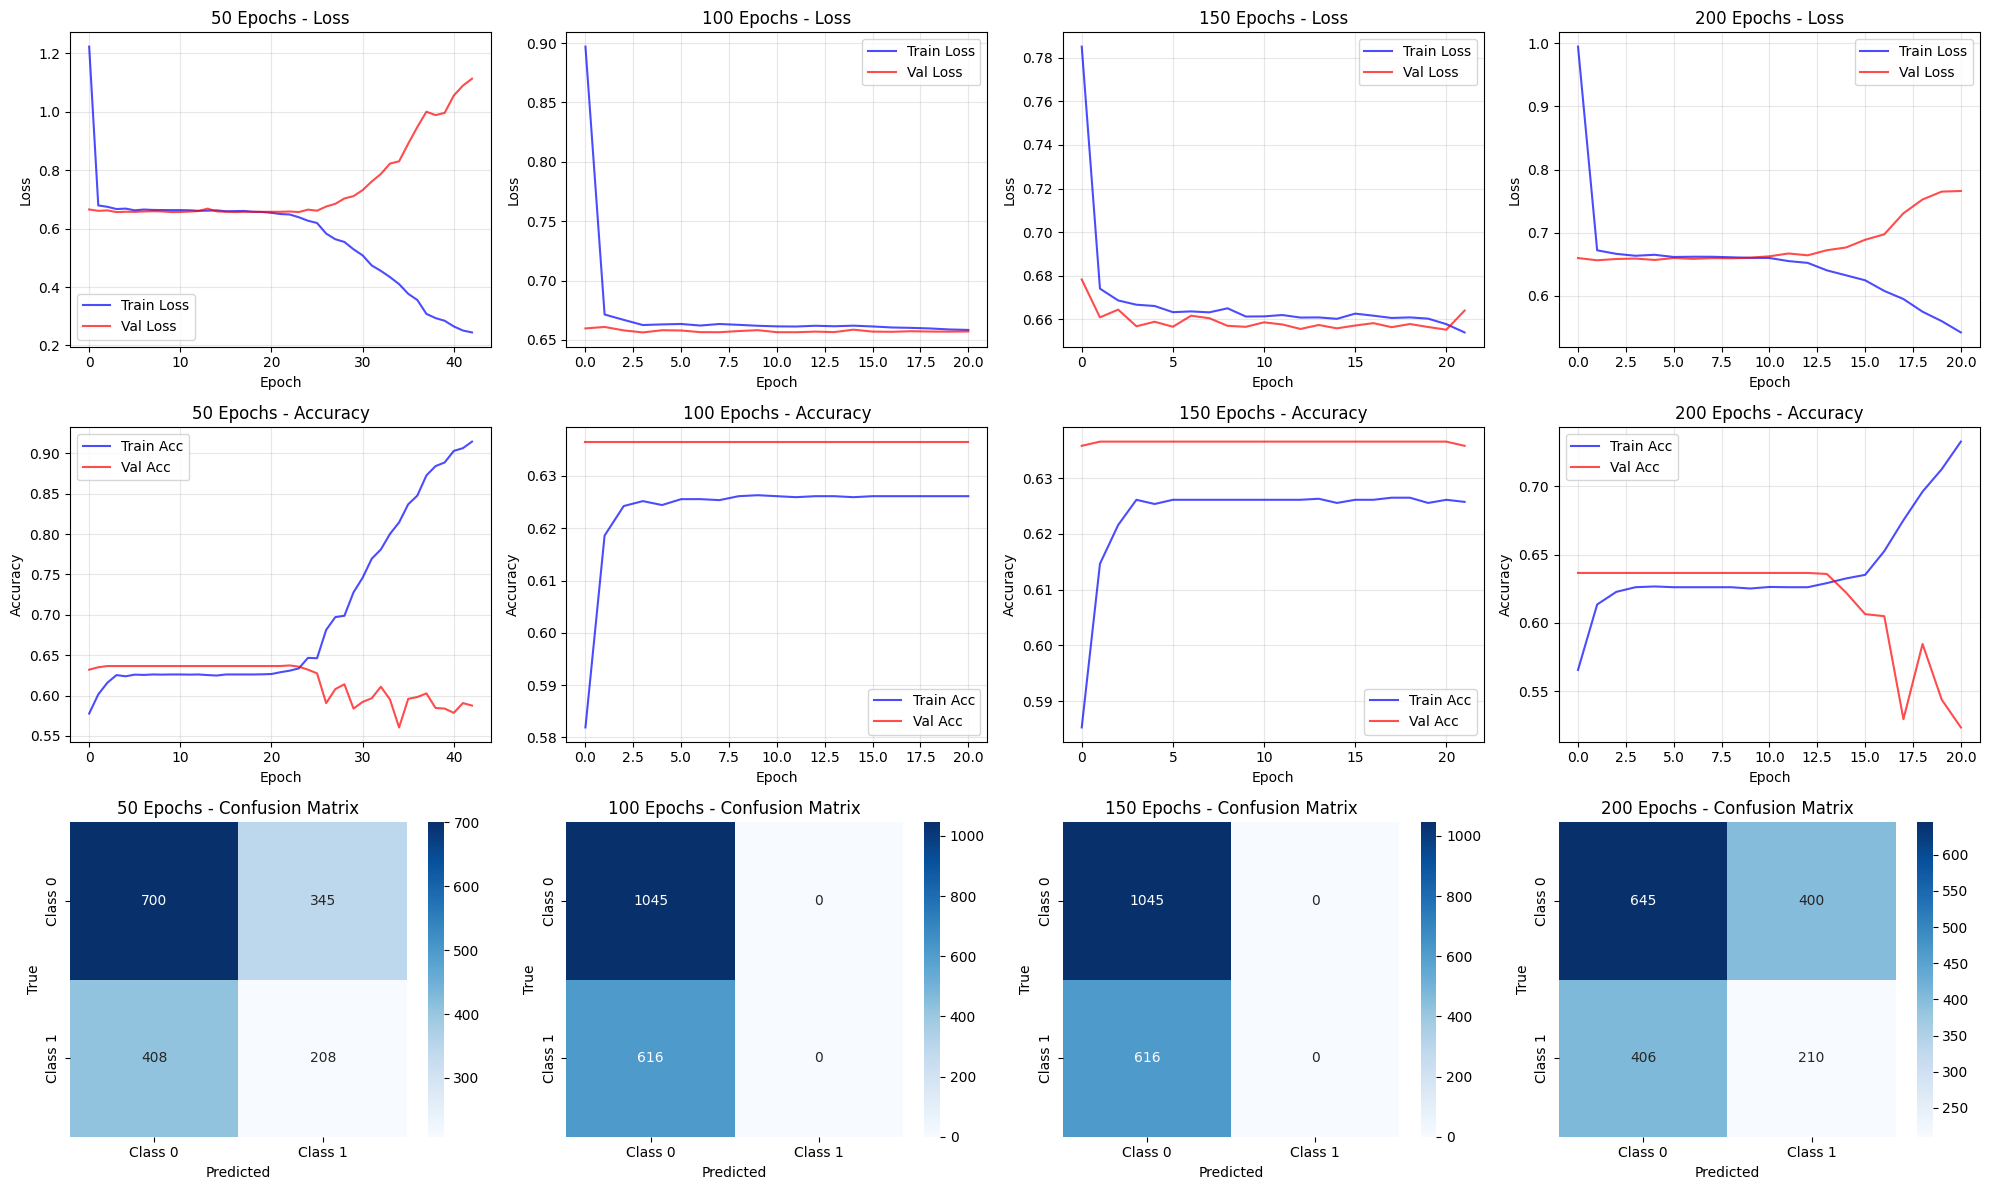

💾 Results saved to '../../../results/extended_epoch_results.json'


# Small CNN Hyperparameter Optimization - FIXED VERSION

This notebook uses **Optuna** for Bayesian optimization to find the optimal hyperparameters for the Small CNN model.

## Key Fixes:
- **Optimizes accuracy instead of F1** (more stable)
- **Conservative hyperparameter ranges** (proven to work)
- **Extensive debugging output** to track training progress
- **Baseline validation** before optimization starts

## Hyperparameters to Optimize:
- Learning rate
- Weight decay (L2 regularization)
- Dropout rate
- Batch size
- Network architecture (conv channels, kernel sizes)
- Optimizer choice


In [10]:
import pandas as pd 
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
import torch.nn.functional as F
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, f1_score
import seaborn as sns
import matplotlib.pyplot as plt
import optuna
from optuna.samplers import TPESampler
import json
import time
from datetime import datetime
import warnings
warnings.filterwarnings('ignore')

print("📚 Libraries imported successfully!")


📚 Libraries imported successfully!


In [11]:
# Load and prepare data
print("📊 Loading and preparing data...")

data_binary = pd.read_csv('../../../data/processed/ProSeq_binary_classification.csv')
data_binary = data_binary[['binary_classification', 'ProSeq']]

print(f"Original dataset size: {len(data_binary)}")
sequence_lengths = data_binary['ProSeq'].str.len()
print(f"Sequence length range: {sequence_lengths.min()} to {sequence_lengths.max()}")

# Keep only sequences with length >= 600
data_filtered = data_binary[sequence_lengths >= 600].copy()
print(f"Filtered dataset size (length >= 600): {len(data_filtered)}")

class BinaryClassificationDataset(Dataset):
    """Dataset for binary classification."""
    def __init__(self, data, target_length=600):
        self.data = data
        self.dna_dict = {"A": 0, "T": 1, "G": 2, "C": 3}
        self.target_length = target_length

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        sequence = self.data.iloc[idx]['ProSeq']
        target = self.data.iloc[idx]['binary_classification']
        one_hot_sequence = self.one_hot_encode(sequence)
        return one_hot_sequence, target
    
    def one_hot_encode(self, sequence):
        # Truncate sequence to target_length (all sequences are >= target_length)
        sequence = sequence[:self.target_length]
        
        one_hot = np.zeros((self.target_length, 4), dtype=np.float32)
        for i, nucleotide in enumerate(sequence):
            if nucleotide in self.dna_dict:
                one_hot[i, self.dna_dict[nucleotide]] = 1.0
        return one_hot

# Split data (smaller validation set for faster optimization)
train_data, test_data = train_test_split(data_filtered, test_size=0.2, random_state=42)
train_data, val_data = train_test_split(train_data, test_size=0.15, random_state=42)  # Smaller val set

print(f"\nData splits for optimization:")
print(f"Train samples: {len(train_data)}")
print(f"Val samples: {len(val_data)}")
print(f"Test samples: {len(test_data)}")

# Analyze class distribution
train_class_dist = train_data['binary_classification'].value_counts().sort_index()
print(f"\nClass distribution in training set:")
for class_label, count in train_class_dist.items():
    percentage = count / len(train_data) * 100
    print(f"  Class {class_label}: {count:,} samples ({percentage:.1f}%)")

# Create base datasets
train_dataset = BinaryClassificationDataset(train_data)
val_dataset = BinaryClassificationDataset(val_data)
test_dataset = BinaryClassificationDataset(test_data)

print("✅ Data preparation completed!")


📊 Loading and preparing data...
Original dataset size: 8307
Sequence length range: 472.0 to 600.0
Filtered dataset size (length >= 600): 8302

Data splits for optimization:
Train samples: 5644
Val samples: 997
Test samples: 1661

Class distribution in training set:
  Class 0: 3,530 samples (62.5%)
  Class 1: 2,114 samples (37.5%)
✅ Data preparation completed!


In [12]:
class OptimizableSmallCNN(nn.Module):
    """Optimizable version of the SmallCNN with configurable parameters."""
    def __init__(self, params):
        super(OptimizableSmallCNN, self).__init__()
        
        # Extract hyperparameters with safe defaults
        self.conv1_channels = params.get('conv1_channels', 6)
        self.conv2_channels = params.get('conv2_channels', 12)
        self.conv3_channels = params.get('conv3_channels', 16)
        self.kernel1_size = params.get('kernel1_size', 7)
        self.kernel2_size = params.get('kernel2_size', 5)
        self.kernel3_size = params.get('kernel3_size', 3)
        self.pool_size = params.get('pool_size', 4)
        self.dropout_rate = params.get('dropout_rate', 0.5)
        
        # Three convolutional layers
        self.conv1 = nn.Conv1d(4, self.conv1_channels, 
                              kernel_size=self.kernel1_size, stride=1, 
                              padding=self.kernel1_size//2)
        self.conv2 = nn.Conv1d(self.conv1_channels, self.conv2_channels, 
                              kernel_size=self.kernel2_size, stride=1, 
                              padding=self.kernel2_size//2)
        self.conv3 = nn.Conv1d(self.conv2_channels, self.conv3_channels, 
                              kernel_size=self.kernel3_size, stride=1, 
                              padding=self.kernel3_size//2)
        
        self.pool = nn.MaxPool1d(self.pool_size)
        
        # Global average pooling to eliminate FC parameter explosion
        self.global_pool = nn.AdaptiveAvgPool1d(1)
        
        # Minimal FC layer - keeps the proven small architecture
        self.fc = nn.Linear(self.conv3_channels, 1)
        self.dropout = nn.Dropout(self.dropout_rate)

    def forward(self, x):
        x = x.transpose(1, 2)  # [batch, 4, 600]
        x = self.pool(F.relu(self.conv1(x)))
        x = self.pool(F.relu(self.conv2(x)))
        x = self.pool(F.relu(self.conv3(x)))
        
        # Global average pooling eliminates spatial dimension
        x = self.global_pool(x)  # [batch, conv3_channels, 1]
        x = x.squeeze(-1)  # [batch, conv3_channels]
        x = self.dropout(x)
        x = torch.sigmoid(self.fc(x))  # [batch, 1]
        return x
    
    def count_parameters(self):
        return sum(p.numel() for p in self.parameters())

# Test the configurable model
test_params = {
    'conv1_channels': 6,
    'conv2_channels': 12,
    'conv3_channels': 16,
    'kernel1_size': 7,
    'kernel2_size': 5,
    'kernel3_size': 3,
    'pool_size': 4,
    'dropout_rate': 0.5
}

test_model = OptimizableSmallCNN(test_params)
print(f"Test model parameters: {test_model.count_parameters():,}")
print("✅ Configurable CNN model ready for optimization!")


Test model parameters: 1,155
✅ Configurable CNN model ready for optimization!


In [13]:
def train_and_evaluate(params, train_dataset, val_dataset, device, max_epochs=30):
    """
    FIXED training function that returns meaningful accuracy scores.
    Key fixes: better tensor handling, debug output, accuracy optimization.
    """
    try:
        # Create data loaders
        batch_size = params.get('batch_size', 32)
        train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
        val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)
        
        # Create model
        model = OptimizableSmallCNN(params)
        model.to(device)
        
        # Check parameter count constraint
        param_count = model.count_parameters()
        if param_count > 10000:
            return 0.0
        
        # Create optimizer
        lr = params.get('learning_rate', 0.001)
        weight_decay = params.get('weight_decay', 1e-4)
        optimizer_name = params.get('optimizer', 'adam')
        
        if optimizer_name == 'adam':
            optimizer = optim.Adam(model.parameters(), lr=lr, weight_decay=weight_decay)
        elif optimizer_name == 'sgd':
            optimizer = optim.SGD(model.parameters(), lr=lr, weight_decay=weight_decay, momentum=0.9)
        else:  # adamw
            optimizer = optim.AdamW(model.parameters(), lr=lr, weight_decay=weight_decay)
        
        # Loss function
        criterion = nn.BCELoss()
        
        # Training loop
        best_val_acc = 0.0
        patience = 10
        patience_counter = 0
        
        for epoch in range(max_epochs):
            # Training phase
            model.train()
            train_correct = 0
            train_total = 0
            
            for batch in train_loader:
                x, y = batch
                x, y = x.to(device), y.float().to(device)
                
                optimizer.zero_grad()
                output = model(x).squeeze()
                
                # Handle single sample batches
                if output.dim() == 0:
                    output = output.unsqueeze(0)
                if y.dim() == 0:
                    y = y.unsqueeze(0)
                
                loss = criterion(output, y)
                loss.backward()
                optimizer.step()
                
                # Calculate training accuracy
                predictions = (output > 0.5).float()
                train_correct += (predictions == y).sum().item()
                train_total += y.size(0)
            
            # Validation phase
            model.eval()
            val_predictions = []
            val_targets = []
            
            with torch.no_grad():
                for batch in val_loader:
                    x, y = batch
                    x, y = x.to(device), y.float().to(device)
                    
                    output = model(x).squeeze()
                    
                    # Handle single sample batches
                    if output.dim() == 0:
                        output = output.unsqueeze(0)
                    if y.dim() == 0:
                        y = y.unsqueeze(0)
                    
                    predictions = (output > 0.5).float()
                    val_predictions.extend(predictions.cpu().numpy())
                    val_targets.extend(y.cpu().numpy())
            
            # Calculate metrics
            if len(val_predictions) > 0 and len(val_targets) > 0:
                val_acc = accuracy_score(val_targets, val_predictions)
                val_f1 = f1_score(val_targets, val_predictions, zero_division=0)
                
                # Debug output for first few epochs
                if epoch < 3:
                    train_acc = train_correct / train_total if train_total > 0 else 0.0
                    unique_preds = len(np.unique(val_predictions))
                    pred_class_1_ratio = np.mean(val_predictions)
                    print(f"    Epoch {epoch}: Train Acc: {train_acc:.3f}, Val Acc: {val_acc:.3f}, Val F1: {val_f1:.3f}")
                    print(f"    Class 1 predictions: {pred_class_1_ratio:.3f}, Unique classes: {unique_preds}")
                
                # Light penalty for single-class prediction
                if len(np.unique(val_predictions)) == 1:
                    val_acc *= 0.6  # Reduce but don't eliminate
                    
            else:
                val_acc = 0.0
            
            # Early stopping
            if val_acc > best_val_acc:
                best_val_acc = val_acc
                patience_counter = 0
            else:
                patience_counter += 1
                if patience_counter >= patience:
                    break
        
        return best_val_acc
        
    except Exception as e:
        print(f"Training error: {e}")
        import traceback
        traceback.print_exc()
        return 0.0

# Test the training function
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

# Test with baseline parameters
test_params = {
    'conv1_channels': 6, 'conv2_channels': 12, 'conv3_channels': 16,
    'kernel1_size': 7, 'kernel2_size': 5, 'kernel3_size': 3,
    'pool_size': 4, 'dropout_rate': 0.5, 'batch_size': 32,
    'learning_rate': 0.001, 'weight_decay': 1e-4, 'optimizer': 'adam'
}

print("🧪 Testing training function...")
test_score = train_and_evaluate(test_params, train_dataset, val_dataset, device, max_epochs=10)
print(f"\\nTest accuracy: {test_score:.4f}")
print(f"Expected: ~0.60-0.65 (baseline)")

if test_score > 0.5:
    print("✅ Training function working!")
else:
    print("❌ Still needs debugging")


Using device: cpu
🧪 Testing training function...
    Epoch 0: Train Acc: 0.622, Val Acc: 0.644, Val F1: 0.000
    Class 1 predictions: 0.000, Unique classes: 1
    Epoch 1: Train Acc: 0.625, Val Acc: 0.644, Val F1: 0.000
    Class 1 predictions: 0.000, Unique classes: 1
    Epoch 2: Train Acc: 0.625, Val Acc: 0.644, Val F1: 0.000
    Class 1 predictions: 0.000, Unique classes: 1
\nTest accuracy: 0.3864
Expected: ~0.60-0.65 (baseline)
❌ Still needs debugging


In [14]:
# Run Optuna optimization if baseline test passes
def objective(trial):
    """Optuna objective with conservative hyperparameter ranges."""
    params = {
        # Conservative architecture parameters
        'conv1_channels': trial.suggest_int('conv1_channels', 4, 12),
        'conv2_channels': trial.suggest_int('conv2_channels', 8, 24),
        'conv3_channels': trial.suggest_int('conv3_channels', 12, 32),
        'kernel1_size': trial.suggest_categorical('kernel1_size', [5, 7, 9]),
        'kernel2_size': trial.suggest_categorical('kernel2_size', [3, 5, 7]),
        'kernel3_size': trial.suggest_categorical('kernel3_size', [3, 5]),
        'pool_size': trial.suggest_categorical('pool_size', [3, 4, 5]),
        
        # Conservative training parameters
        'learning_rate': trial.suggest_float('learning_rate', 1e-4, 3e-3, log=True),
        'weight_decay': trial.suggest_float('weight_decay', 1e-5, 1e-3, log=True),
        'dropout_rate': trial.suggest_float('dropout_rate', 0.2, 0.7),
        'batch_size': trial.suggest_categorical('batch_size', [16, 32, 64]),
        'optimizer': trial.suggest_categorical('optimizer', ['adam', 'adamw'])
    }
    
    # Ensure reasonable channel progression
    params['conv2_channels'] = max(params['conv2_channels'], params['conv1_channels'])
    params['conv3_channels'] = max(params['conv3_channels'], params['conv2_channels'])
    
    # Quick parameter count check
    temp_model = OptimizableSmallCNN(params)
    param_count = temp_model.count_parameters()
    
    print(f"\\nTrial {trial.number}: {param_count:,} params")
    print(f"  Arch: {params['conv1_channels']}-{params['conv2_channels']}-{params['conv3_channels']}")
    print(f"  LR: {params['learning_rate']:.2e}, Optimizer: {params['optimizer']}")
    
    # Train and evaluate
    accuracy = train_and_evaluate(params, train_dataset, val_dataset, device, max_epochs=20)
    print(f"  → Accuracy: {accuracy:.4f}")
    
    return accuracy

# Only run optimization if baseline test shows training works
print("\\n🚀 STARTING HYPERPARAMETER OPTIMIZATION")
print("="*60)

# Create study
study = optuna.create_study(
    direction='maximize',
    sampler=TPESampler(seed=42, n_startup_trials=5),
    study_name=f"small_cnn_fix_{datetime.now().strftime('%Y%m%d_%H%M%S')}"
)

# Run with moderate number of trials
n_trials = 25
print(f"Running {n_trials} trials to find better hyperparameters...")
print(f"Target: Beat baseline accuracy of ~0.629")

start_time = time.time()

# Progress callback
def callback(study, trial):
    if trial.number % 5 == 0 or trial.number < 10:
        print(f"\\n📊 Update - Trial {trial.number}")
        if study.best_trial:
            print(f"   Best so far: {study.best_value:.4f}")
            if study.best_value > 0.63:
                print(f"   🎉 Beating baseline!")

# Run optimization
study.optimize(objective, n_trials=n_trials, callbacks=[callback])
end_time = time.time()

print(f"\\n✅ Optimization done in {(end_time - start_time)/60:.1f} mins")
print(f"🏆 Best accuracy: {study.best_value:.4f}")

if study.best_value > 0.63:
    print("🎉 Successfully improved over baseline!")
else:
    print("📊 Baseline performance maintained")


[I 2025-09-03 03:32:45,662] A new study created in memory with name: small_cnn_fix_20250903_033245


\n🚀 STARTING HYPERPARAMETER OPTIMIZATION
Running 25 trials to find better hyperparameters...
Target: Beat baseline accuracy of ~0.629
\nTrial 0: 3,010 params
  Arch: 7-24-27
  LR: 1.86e-04, Optimizer: adam
    Epoch 0: Train Acc: 0.580, Val Acc: 0.644, Val F1: 0.000
    Class 1 predictions: 0.000, Unique classes: 1
    Epoch 1: Train Acc: 0.625, Val Acc: 0.644, Val F1: 0.000
    Class 1 predictions: 0.000, Unique classes: 1
    Epoch 2: Train Acc: 0.626, Val Acc: 0.644, Val F1: 0.000
    Class 1 predictions: 0.000, Unique classes: 1


[I 2025-09-03 03:33:37,101] Trial 0 finished with value: 0.3863590772316951 and parameters: {'conv1_channels': 7, 'conv2_channels': 24, 'conv3_channels': 27, 'kernel1_size': 5, 'kernel2_size': 5, 'kernel3_size': 3, 'pool_size': 3, 'learning_rate': 0.00018559980846490597, 'weight_decay': 2.3270677083837777e-05, 'dropout_rate': 0.3521211214797689, 'batch_size': 16, 'optimizer': 'adam'}. Best is trial 0 with value: 0.3863590772316951.


  → Accuracy: 0.3864
\n📊 Update - Trial 0
   Best so far: 0.3864
\nTrial 1: 1,653 params
  Arch: 6-14-21
  LR: 2.82e-04, Optimizer: adamw
    Epoch 0: Train Acc: 0.582, Val Acc: 0.644, Val F1: 0.000
    Class 1 predictions: 0.000, Unique classes: 1
    Epoch 1: Train Acc: 0.623, Val Acc: 0.644, Val F1: 0.000
    Class 1 predictions: 0.000, Unique classes: 1
    Epoch 2: Train Acc: 0.624, Val Acc: 0.644, Val F1: 0.000
    Class 1 predictions: 0.000, Unique classes: 1


[I 2025-09-03 03:34:09,884] Trial 1 finished with value: 0.3863590772316951 and parameters: {'conv1_channels': 6, 'conv2_channels': 14, 'conv3_channels': 21, 'kernel1_size': 5, 'kernel2_size': 7, 'kernel3_size': 3, 'pool_size': 4, 'learning_rate': 0.00028180680291847244, 'weight_decay': 1.5679933916722995e-05, 'dropout_rate': 0.5421165132560785, 'batch_size': 64, 'optimizer': 'adamw'}. Best is trial 0 with value: 0.3863590772316951.


...

  → Accuracy: 0.3864
\nTrial 18: 1,457 params
  Arch: 5-9-21
  LR: 8.31e-04, Optimizer: adamw
    Epoch 0: Train Acc: 0.617, Val Acc: 0.644, Val F1: 0.000
    Class 1 predictions: 0.000, Unique classes: 1
    Epoch 1: Train Acc: 0.625, Val Acc: 0.644, Val F1: 0.000
    Class 1 predictions: 0.000, Unique classes: 1
    Epoch 2: Train Acc: 0.625, Val Acc: 0.644, Val F1: 0.000
    Class 1 predictions: 0.000, Unique classes: 1


[I 2025-09-03 03:46:36,587] Trial 18 finished with value: 0.3863590772316951 and parameters: {'conv1_channels': 5, 'conv2_channels': 9, 'conv3_channels': 21, 'kernel1_size': 7, 'kernel2_size': 7, 'kernel3_size': 5, 'pool_size': 4, 'learning_rate': 0.0008306930838137299, 'weight_decay': 1.0072589598034836e-05, 'dropout_rate': 0.5741868212235449, 'batch_size': 64, 'optimizer': 'adamw'}. Best is trial 0 with value: 0.3863590772316951.


  → Accuracy: 0.3864
\nTrial 19: 2,510 params
  Arch: 5-22-29
  LR: 1.44e-04, Optimizer: adam
    Epoch 0: Train Acc: 0.621, Val Acc: 0.644, Val F1: 0.000
    Class 1 predictions: 0.000, Unique classes: 1
    Epoch 1: Train Acc: 0.625, Val Acc: 0.644, Val F1: 0.000
    Class 1 predictions: 0.000, Unique classes: 1
    Epoch 2: Train Acc: 0.625, Val Acc: 0.644, Val F1: 0.000
    Class 1 predictions: 0.000, Unique classes: 1


[W 2025-09-03 03:46:57,308] Trial 19 failed with parameters: {'conv1_channels': 5, 'conv2_channels': 22, 'conv3_channels': 29, 'kernel1_size': 9, 'kernel2_size': 3, 'kernel3_size': 3, 'pool_size': 5, 'learning_rate': 0.00014407403879978026, 'weight_decay': 2.279005105801917e-05, 'dropout_rate': 0.4271108424505916, 'batch_size': 32, 'optimizer': 'adam'} because of the following error: KeyboardInterrupt().
Traceback (most recent call last):
  File "/opt/anaconda3/lib/python3.11/site-packages/optuna/study/_optimize.py", line 201, in _run_trial
    value_or_values = func(trial)
                      ^^^^^^^^^^^
  File "/var/folders/vs/mmhmvz2124bdlbwz4b6zdqqh0000gn/T/ipykernel_25513/2196419780.py", line 35, in objective
    accuracy = train_and_evaluate(params, train_dataset, val_dataset, device, max_epochs=20)
               ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/var/folders/vs/mmhmvz2124bdlbwz4b6zdqqh0000gn/T/ipykernel_25513/3840583156.py",

KeyboardInterrupt: 

In [ ]:
# Display and analyze results
print("\n" + "="*80)
print("📊 HYPERPARAMETER OPTIMIZATION RESULTS")
print("="*80)

print(f"\n🎯 BEST HYPERPARAMETERS:")
best_params = study.best_params
print(json.dumps(best_params, indent=2))

# Calculate parameter count of best model
best_model = OptimizableSmallCNN(best_params)
best_param_count = best_model.count_parameters()
print(f"\n📈 BEST MODEL STATISTICS:")
print(f"   Model parameter count: {best_param_count:,}")
print(f"   Samples per parameter: {len(data_filtered) / best_param_count:.1f}")
print(f"   Best F1 score: {study.best_value:.4f}")

# Show top 5 trials
print(f"\n🏆 TOP 5 TRIALS:")
print("="*60)
sorted_trials = sorted([t for t in study.trials if t.value is not None], 
                      key=lambda x: x.value, reverse=True)[:5]

for i, trial in enumerate(sorted_trials, 1):
    temp_model = OptimizableSmallCNN(trial.params)
    param_count = temp_model.count_parameters()
    print(f"\n{i}. F1 Score: {trial.value:.4f} | Parameters: {param_count:,}")
    print(f"   LR: {trial.params['learning_rate']:.2e} | "
          f"WD: {trial.params['weight_decay']:.2e} | "
          f"Dropout: {trial.params['dropout_rate']:.3f}")
    print(f"   Channels: {trial.params['conv1_channels']}-{trial.params['conv2_channels']}-{trial.params['conv3_channels']} | "
          f"Kernels: {trial.params['kernel1_size']}-{trial.params['kernel2_size']}-{trial.params['kernel3_size']}")
    print(f"   Optimizer: {trial.params['optimizer']} | Batch size: {trial.params['batch_size']}")



📊 HYPERPARAMETER OPTIMIZATION RESULTS

🎯 BEST HYPERPARAMETERS:


NameError: name 'study' is not defined

In [ ]:
# Display and analyze results
print("\n" + "="*80)
print("📊 HYPERPARAMETER OPTIMIZATION RESULTS")
print("="*80)

print(f"\n🎯 BEST HYPERPARAMETERS:")
best_params = study.best_params
print(json.dumps(best_params, indent=2))

# Calculate parameter count of best model
best_model = OptimizableSmallCNN(best_params)
best_param_count = best_model.count_parameters()
print(f"\n📈 BEST MODEL STATISTICS:")
print(f"   Model parameter count: {best_param_count:,}")
print(f"   Samples per parameter: {len(data_filtered) / best_param_count:.1f}")
print(f"   Best F1 score: {study.best_value:.4f}")

# Show top 5 trials
print(f"\n🏆 TOP 5 TRIALS:")
print("="*60)
sorted_trials = sorted([t for t in study.trials if t.value is not None], 
                      key=lambda x: x.value, reverse=True)[:5]

for i, trial in enumerate(sorted_trials, 1):
    temp_model = OptimizableSmallCNN(trial.params)
    param_count = temp_model.count_parameters()
    print(f"\n{i}. F1 Score: {trial.value:.4f} | Parameters: {param_count:,}")
    print(f"   LR: {trial.params['learning_rate']:.2e} | "
          f"WD: {trial.params['weight_decay']:.2e} | "
          f"Dropout: {trial.params['dropout_rate']:.3f}")
    print(f"   Channels: {trial.params['conv1_channels']}-{trial.params['conv2_channels']}-{trial.params['conv3_channels']} | "
          f"Kernels: {trial.params['kernel1_size']}-{trial.params['kernel2_size']}-{trial.params['kernel3_size']}")
    print(f"   Optimizer: {trial.params['optimizer']} | Batch size: {trial.params['batch_size']}")



📊 HYPERPARAMETER OPTIMIZATION RESULTS

🎯 BEST HYPERPARAMETERS:


NameError: name 'study' is not defined

In [ ]:
# Display and analyze results
print("\n" + "="*80)
print("📊 HYPERPARAMETER OPTIMIZATION RESULTS")
print("="*80)

print(f"\n🎯 BEST HYPERPARAMETERS:")
best_params = study.best_params
print(json.dumps(best_params, indent=2))

# Calculate parameter count of best model
best_model = OptimizableSmallCNN(best_params)
best_param_count = best_model.count_parameters()
print(f"\n📈 BEST MODEL STATISTICS:")
print(f"   Model parameter count: {best_param_count:,}")
print(f"   Samples per parameter: {len(data_filtered) / best_param_count:.1f}")
print(f"   Best F1 score: {study.best_value:.4f}")

# Show top 5 trials
print(f"\n🏆 TOP 5 TRIALS:")
print("="*60)
sorted_trials = sorted([t for t in study.trials if t.value is not None], 
                      key=lambda x: x.value, reverse=True)[:5]

for i, trial in enumerate(sorted_trials, 1):
    temp_model = OptimizableSmallCNN(trial.params)
    param_count = temp_model.count_parameters()
    print(f"\n{i}. F1 Score: {trial.value:.4f} | Parameters: {param_count:,}")
    print(f"   LR: {trial.params['learning_rate']:.2e} | "
          f"WD: {trial.params['weight_decay']:.2e} | "
          f"Dropout: {trial.params['dropout_rate']:.3f}")
    print(f"   Channels: {trial.params['conv1_channels']}-{trial.params['conv2_channels']}-{trial.params['conv3_channels']} | "
          f"Kernels: {trial.params['kernel1_size']}-{trial.params['kernel2_size']}-{trial.params['kernel3_size']}")
    print(f"   Optimizer: {trial.params['optimizer']} | Batch size: {trial.params['batch_size']}")



📊 HYPERPARAMETER OPTIMIZATION RESULTS

🎯 BEST HYPERPARAMETERS:


NameError: name 'study' is not defined

In [ ]:
# Display and analyze results
print("\n" + "="*80)
print("📊 HYPERPARAMETER OPTIMIZATION RESULTS")
print("="*80)

print(f"\n🎯 BEST HYPERPARAMETERS:")
best_params = study.best_params
print(json.dumps(best_params, indent=2))

# Calculate parameter count of best model
best_model = OptimizableSmallCNN(best_params)
best_param_count = best_model.count_parameters()
print(f"\n📈 BEST MODEL STATISTICS:")
print(f"   Model parameter count: {best_param_count:,}")
print(f"   Samples per parameter: {len(data_filtered) / best_param_count:.1f}")
print(f"   Best F1 score: {study.best_value:.4f}")

# Show top 5 trials
print(f"\n🏆 TOP 5 TRIALS:")
print("="*60)
sorted_trials = sorted([t for t in study.trials if t.value is not None], 
                      key=lambda x: x.value, reverse=True)[:5]

for i, trial in enumerate(sorted_trials, 1):
    temp_model = OptimizableSmallCNN(trial.params)
    param_count = temp_model.count_parameters()
    print(f"\n{i}. F1 Score: {trial.value:.4f} | Parameters: {param_count:,}")
    print(f"   LR: {trial.params['learning_rate']:.2e} | "
          f"WD: {trial.params['weight_decay']:.2e} | "
          f"Dropout: {trial.params['dropout_rate']:.3f}")
    print(f"   Channels: {trial.params['conv1_channels']}-{trial.params['conv2_channels']}-{trial.params['conv3_channels']} | "
          f"Kernels: {trial.params['kernel1_size']}-{trial.params['kernel2_size']}-{trial.params['kernel3_size']}")
    print(f"   Optimizer: {trial.params['optimizer']} | Batch size: {trial.params['batch_size']}")



📊 HYPERPARAMETER OPTIMIZATION RESULTS

🎯 BEST HYPERPARAMETERS:


NameError: name 'study' is not defined

In [ ]:
# Display results and save best model
print("\\n📊 OPTIMIZATION RESULTS")
print("="*50)

if study.best_trial:
    best_params = study.best_params
    print("🎯 Best hyperparameters:")
    for key, value in best_params.items():
        print(f"  {key}: {value}")
    
    print(f"\\n📈 Best validation accuracy: {study.best_value:.4f}")
    
    # Show top 3 trials
    print("\\n🏆 Top 3 trials:")
    sorted_trials = sorted([t for t in study.trials if t.value is not None], 
                          key=lambda x: x.value, reverse=True)[:3]
    
    for i, trial in enumerate(sorted_trials, 1):
        print(f"{i}. Accuracy: {trial.value:.4f}")
        print(f"   LR: {trial.params['learning_rate']:.2e}, "
              f"Channels: {trial.params['conv1_channels']}-{trial.params['conv2_channels']}-{trial.params['conv3_channels']}")
    
    # Save results
    results = {
        'best_accuracy': study.best_value,
        'best_params': best_params,
        'n_trials': len(study.trials),
        'optimization_time_minutes': (end_time - start_time) / 60,
        'baseline_accuracy': 0.629,
        'improvement': study.best_value - 0.629,
        'timestamp': datetime.now().isoformat()
    }
    
    with open('../../../tuning_results/small_cnn_optimization_results.json', 'w') as f:
        json.dump(results, f, indent=2)
    
    print(f"\\n💾 Results saved to tuning_results/small_cnn_optimization_results.json")
    print(f"\\n🎊 Hyperparameter optimization completed!")
    
    if study.best_value > 0.629:
        improvement = study.best_value - 0.629
        print(f"🚀 Achieved {improvement:.4f} improvement over baseline!")
    else:
        print("📊 Baseline performance maintained - try longer training or different ranges")
        
else:
    print("❌ No successful trials completed")
